### 1. Importar Librerias

In [163]:
# Librerias para acceder a los datos
import sqlite3
from sqlalchemy import create_engine
# Librerias para el manejo de datos
import numpy as np
import pandas as pd
# Librerias para el modelado y pruebas
import itertools
from scipy.stats import norm
import statsmodels.tsa.api as smtsa
from statsmodels.tsa import stattools
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
import statsmodels.tsa.arima.model as arima_model
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, q_stat, bds
from statsmodels.stats.diagnostic import acorr_ljungbox
# Deep Learning
from scipy.stats import norm
import tensorflow as tf
from tensorflow import keras
import sklearn as sk
from sklearn.metrics import mean_absolute_error
# Librerias de visualización
import seaborn as sns
import matplotlib.pyplot as plt
from windrose import WindroseAxes

### 2. Importar Datos

In [119]:
database_path = 'C:/Users/Martin Bornacelly/Desktop/Proyectos/SQL-LITE/Wind Speed/Database/WindSpeed.db'
connection = sqlite3.connect(database_path)
cursor = connection.cursor()

In [120]:
query = cursor.execute('''SELECT * FROM WeatherBrazilia ORDER BY Date''')
# Extraer Nombre de Columnas
column_names = [column_name[0] for column_name in query.description]
# Extraer Información
df = pd.DataFrame(query.fetchall())

In [121]:
# Añadir nombre a columnas
df.columns = column_names

In [122]:
# Crear Columnas de Año, Mes, Día y Hora
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Hour'] = df['Date'].dt.hour

In [123]:
# Cambiar el index por la fecha
df.index = df['Date']
# Borrar la columna fecha
df = df.drop(columns=['Date'])
# Periodicida horaria


In [124]:
lastBadReading_WindSpeed = max(df.index[df['WindSpeed'] == -9999])
lastBadReading_WindGust = max(df.index[df['WindGust'] == -9999])
lastBadReading_WindDirection = max(df.index[df['WindDirection'] == -9999])

lastBadReading = max([lastBadReading_WindDirection,lastBadReading_WindGust,lastBadReading_WindDirection])

print(f'Fecha de ultimo dato faltante: {lastBadReading}')

# Tomar los datos despues de la ultima fecha con datos faltantes
df = df[df.index > lastBadReading]
# Tomar solo las columnas de interes
df = df[['WindSpeed','WindGust','WindDirection','Year','Month','Day','Hour']]

Fecha de ultimo dato faltante: 2018-05-10 04:00:00


In [125]:
df.asfreq('H')

C:\Users\Martin Bornacelly\AppData\Local\Temp\ipykernel_32272\1822055459.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df.asfreq('H')


,WindSpeed,WindGust,WindDirection,Year,Month,Day,Hour
Date,,,,,,,
2018-05-10 05:00:00,2.9,6.9,114.0,2018,5,10,5
2018-05-10 06:00:00,2.8,5.9,110.0,2018,5,10,6
2018-05-10 07:00:00,2.1,6.2,107.0,2018,5,10,7
2018-05-10 08:00:00,2.6,5.6,101.0,2018,5,10,8
2018-05-10 09:00:00,3.3,6.9,102.0,2018,5,10,9
...,...,...,...,...,...,...,...
2024-12-31 19:00:00,3.3,6.3,351.0,2024,12,31,19
2024-12-31 20:00:00,3.7,7.4,348.0,2024,12,31,20
2024-12-31 21:00:00,3.4,12.1,3.0,2024,12,31,21


In [126]:
df.count()

WindSpeed        58267
WindGust         58267
WindDirection    58267
Year             58267
Month            58267
Day              58267
Hour             58267
dtype: int64

In [127]:
df.shape

(58267, 7)

### 3. Modelos Utilizados

#### 3.0 Funciones

In [128]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true[y_true != 0] - y_pred[y_true != 0]) / y_true[y_true != 0])) * 100

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def makeXY(ts, nb_timesteps):
    x,y = [], []
    for i in range(nb_timesteps,len(ts)):
        x.append(list(ts[i-nb_timesteps:i])) #Regressors
        y.append(ts[i]) #Target
    return np.array(x), np.array(y)

def bds_test(series, m=2):
    return bds(series, m=m)

def apply_test(y_true,y_pred,title=""):
    residuals = y_true - y_pred
    mape_value = mape(y_true,y_pred)
    print(f"MAPE: {mape_value}")
    mae_value = mae(y_true,y_pred)
    print(f"MAE: {mae_value}")
    mse_value = mse(y_true,y_pred)
    print(f"MSE: {mse_value}")
    rmse_value = rmse(y_true,y_pred)
    print(f"RMSE: {rmse_value}")
    jungbox_value = acorr_ljungbox(residuals,lags=20,return_df=True)
    print(jungbox_value)

    pd.DataFrame({"test": y_true, "predictions": y_pred,"residuals": residuals}).to_csv(f"{title} Info.csv")

    return [mape_value, mae_value, mse_value, rmse_value, jungbox_value]

def show_comparison(y_true,y_pred,title):
    plt.figure(figsize=(14,3))
    plt.plot(y_true)
    plt.plot(y_pred)
    plt.legend(['Test','Prediction'])
    plt.title(title)

def diebold_mariano_test(errors_1, errors_2, h=1):
    d_t = errors_1**2 - errors_2**2  # Loss differential
    mean_d_t = np.mean(d_t)
    var_d_t = np.var(d_t, ddof=1)

    dm_stat = mean_d_t / np.sqrt(var_d_t / len(d_t))
    p_value = 2 * (1 - norm.cdf(np.abs(dm_stat)))  # Two-tailed test
    return dm_stat, p_value

#### 3.1 Separar datos

In [129]:
last_seven_days = 24*7

In [130]:
# Separar Datos de entrenamiento y prueba
train_data = df['WindSpeed'][:int(df.shape[0]*0.9)] 
validation_data = df['WindSpeed'][int(df.shape[0]*0.9):-last_seven_days]
test_data = df['WindSpeed'][-last_seven_days:]
# Separar Datos para redes neuronales
train_x, train_y = makeXY(train_data.to_list(),48)
validation_x, validation_y = makeXY(validation_data.to_list(),48)
test_x, test_y = makeXY(test_data.to_list(),48)

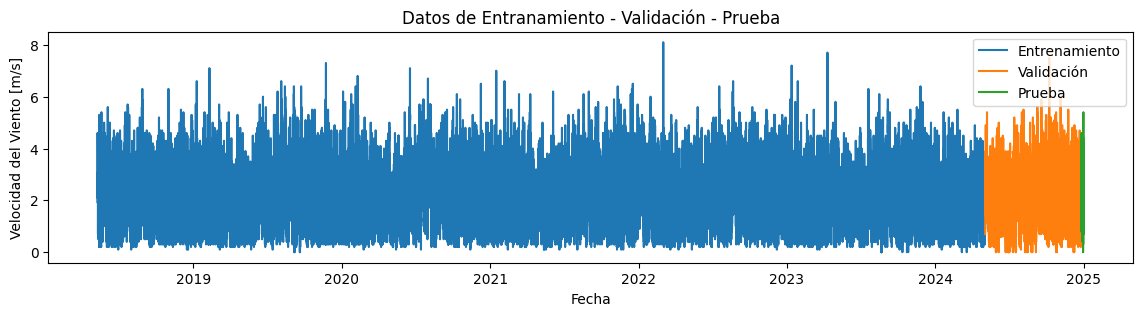

In [131]:
plt.figure(figsize=(14,3))
plt.title("Datos de Entranamiento - Validación - Prueba")
plt.plot(train_data)
plt.plot(validation_data)
plt.plot(test_data)
plt.xlabel("Fecha")
plt.ylabel("Velocidad del Viento [m/s]")
plt.legend(['Entrenamiento','Validación','Prueba'])
plt.show()

#### 3.1 Suavización Exponencial

#### 3.2 Suavización Exponencial (Holt Winters)

In [151]:
def ses_optimizer(train, validation, alphas, step):

    best_alpha, best_mae = None, float("inf")

    for alpha in alphas:
        ses_model = SimpleExpSmoothing(train).fit(smoothing_level=alpha, optimized=False)
        y_pred = ses_model.forecast(step)
        mae = mean_absolute_error(validation, y_pred)

        if mae < best_mae:
            best_alpha, best_mae = alpha, mae

    return best_alpha, best_mae

def ses_model_tuning(train, validation, step):
    
    alphas = np.arange(0.8, 1, 0.01)
    best_alpha, best_mae = ses_optimizer(train, validation, alphas, step=validation.shape[0])
    
    new_train = pd.concat([train,validation])
    
    final_model = SimpleExpSmoothing(new_train).fit(smoothing_level=best_alpha, optimized=False)
    y_pred = final_model.forecast(step)
    
    return y_pred

In [152]:
ses_pred_168h = ses_model_tuning(train_data,validation_data,168)

C:\Users\Martin Bornacelly\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\Martin Bornacelly\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\Martin Bornacelly\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\Martin Bornacelly\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\Martin Bornacelly\AppData\Roaming\Python\Python

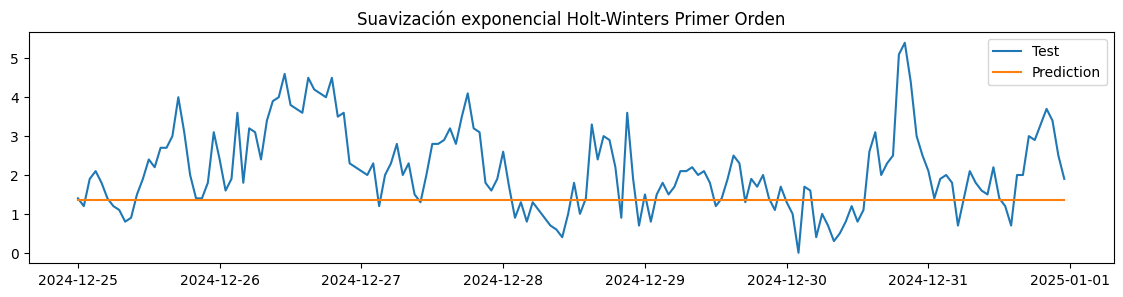

In [153]:
show_comparison(test_data,ses_pred_168h,'Suavización exponencial Holt-Winters Primer Orden')

In [154]:
ses_results = apply_test(test_data,ses_pred_168h,'Suavización exponencial Holt-Winters Primer Orden')

MAPE: 45.210569965962186
MAE: 0.9895534975545056
MSE: 1.7138242967566812
RMSE: 1.3091311228279165
       lb_stat     lb_pvalue
1    97.051750  6.753883e-23
2   157.422628  6.548032e-35
3   201.554624  1.946457e-43
4   232.840004  3.229815e-49
5   253.417450  1.015791e-52
6   266.362037  1.301952e-54
7   270.169813  1.400759e-54
8   270.536758  7.564738e-54
9   270.672998  4.262912e-53
10  270.715020  2.363888e-52
11  270.856077  1.182349e-51
12  270.936360  5.796012e-51
13  271.876240  1.797963e-50
14  274.723289  2.156276e-50
15  276.544764  4.097002e-50
16  277.118500  1.367231e-49
17  277.889814  4.027474e-49
18  277.969464  1.597575e-48
19  277.969662  6.389380e-48
20  279.302030  1.332523e-47


In [155]:
def des_optimizer(train, validation, alphas, betas, trend, step):

    best_alpha, best_beta, best_mae = None, None, float("inf")

    for alpha in alphas:
        for beta in betas:
            des_model = ExponentialSmoothing(train, trend=trend).fit(smoothing_level=alpha, smoothing_slope=beta)
            y_pred = des_model.forecast(step)
            mae = mean_absolute_error(validation, y_pred)
            if mae < best_mae:
                best_alpha, best_beta, best_mae = alpha, beta, mae

    print(f"best alpha = {best_alpha}, best beta = {best_beta}")

    return best_alpha, best_beta, best_mae

def des_model_tuning(train, validation, step, trend):
    
    alphas = np.arange(0.001, 0.01, 0.001)
    betas = np.arange(0.001, 0.01, 0.001)
    best_alpha, best_beta, best_mae = des_optimizer(train, validation, alphas, betas, trend=trend, step=validation.shape[0])

    new_train = pd.concat([train,validation])

    final_model = ExponentialSmoothing(new_train, trend=trend).fit(smoothing_level=best_alpha, smoothing_slope=best_beta)
    y_pred = final_model.forecast(step)
    
    return y_pred

In [156]:
des_pred_168h = des_model_tuning(train_data,validation_data,168,'add')

C:\Users\Martin Bornacelly\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\Martin Bornacelly\AppData\Local\Temp\ipykernel_32272\2510264046.py:7: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  des_model = ExponentialSmoothing(train, trend=trend).fit(smoothing_level=alpha, smoothing_slope=beta)
C:\Users\Martin Bornacelly\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\Martin Bornacelly\AppData\Local\Temp\ipykernel_32272\2510264046.py:7: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  des_model = ExponentialSmoothing(train, trend=trend).fit(smoothing_level=alpha, sm

best alpha = 0.005, best beta = 0.005


C:\Users\Martin Bornacelly\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\Martin Bornacelly\AppData\Local\Temp\ipykernel_32272\2510264046.py:25: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  final_model = ExponentialSmoothing(new_train, trend=trend).fit(smoothing_level=best_alpha, smoothing_slope=best_beta)


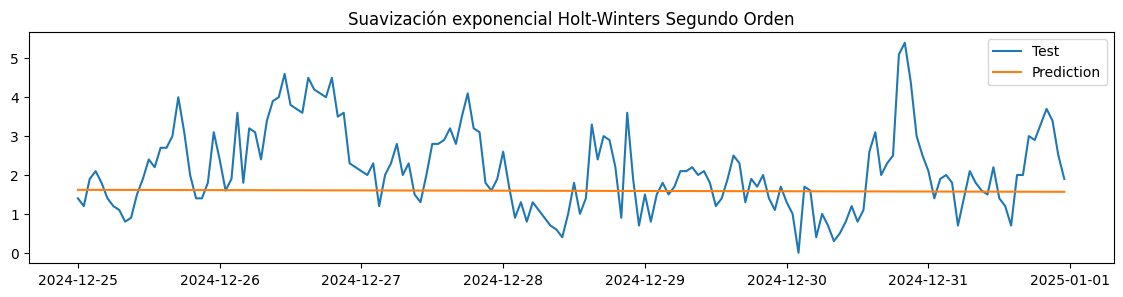

In [157]:
show_comparison(test_data,des_pred_168h,'Suavización exponencial Holt-Winters Segundo Orden')

In [158]:
des_results = apply_test(test_data,des_pred_168h,'Suavización exponencial Holt-Winters Segundo Orden')

MAPE: 45.48949737043373
MAE: 0.8851460195738183
MSE: 1.380041790436329
RMSE: 1.1747517995033372
       lb_stat     lb_pvalue
1    96.737815  7.914316e-23
2   156.670624  9.536880e-35
3   200.318833  3.599740e-43
4   231.106578  7.627262e-49
5   251.208524  3.025579e-52
6   263.723031  4.776001e-54
7   267.256007  5.853327e-54
8   267.532247  3.286804e-53
9   267.613496  1.891992e-52
10  267.698718  1.021624e-51
11  267.913381  4.904070e-51
12  268.050494  2.326538e-50
13  269.173653  6.575944e-50
14  272.342786  6.731583e-50
15  274.414619  1.130724e-49
16  275.125718  3.522033e-49
17  276.053837  9.600214e-49
18  276.183485  3.707281e-48
19  276.190956  1.472929e-47
20  277.373397  3.285437e-47


In [159]:
def tes_optimizer(train, validation, abg, trend, seasonal,  seasonal_periods, step):
    
    best_alpha, best_beta, best_gamma, best_mae = None, None, None, float("inf")
    for comb in abg:
        tes_model = ExponentialSmoothing(train, trend=trend, seasonal=seasonal, seasonal_periods=seasonal_periods).\
            fit(smoothing_level=comb[0], smoothing_slope=comb[1], smoothing_seasonal=comb[2])
        y_pred = tes_model.forecast(step)
        try:
            mae = mean_absolute_error(validation, y_pred)
        except:
            mae = 9999
        if mae < best_mae:
            best_alpha, best_beta, best_gamma, best_mae = comb[0], comb[1], comb[2], mae

    return best_alpha, best_beta, best_gamma, best_mae

def tes_model_tuning(train, validation, step, trend, seasonal, seasonal_periods):
    
    alphas = betas = gammas = np.arange(0.10, 1, 0.10)
    abg = list(itertools.product(alphas, betas, gammas))
    best_alpha, best_beta, best_gamma, best_mae = tes_optimizer(train, validation, abg=abg, trend=trend, seasonal=seasonal, seasonal_periods=seasonal_periods, step=validation.shape[0])

    new_train = pd.concat([train,validation])

    final_model = ExponentialSmoothing(new_train, trend=trend, seasonal=seasonal).fit(smoothing_level=best_alpha, smoothing_slope=best_beta, smoothing_seasonal=best_gamma)
    y_pred = final_model.forecast(step)
    
    return y_pred

In [160]:
tes_pred_168h = tes_model_tuning(train_data,validation_data,168,'add','add',24)

C:\Users\Martin Bornacelly\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\Martin Bornacelly\AppData\Local\Temp\ipykernel_32272\1720510490.py:6: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  fit(smoothing_level=comb[0], smoothing_slope=comb[1], smoothing_seasonal=comb[2])
C:\Users\Martin Bornacelly\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\Martin Bornacelly\AppData\Local\Temp\ipykernel_32272\1720510490.py:6: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  fit(smoothing_level=comb[0], smoothing_slope=comb[1], smoothing_seasonal=comb[2])
C:\Users\Martin Born

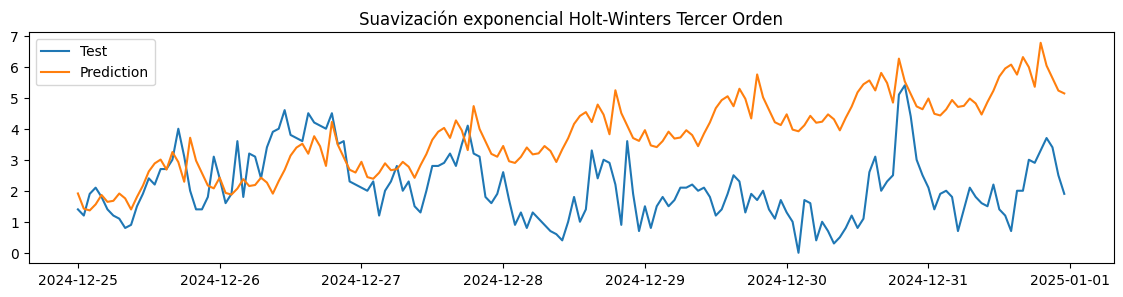

In [161]:
show_comparison(test_data,tes_pred_168h,'Suavización exponencial Holt-Winters Tercer Orden')

In [162]:
tes_results = apply_test(test_data,tes_pred_168h,'Suavización exponencial Holt-Winters Tercer Orden')

MAPE: 141.94853661405395
MAE: 1.8790248512611105
MSE: 5.120644150335765
RMSE: 2.2628840337798497
        lb_stat      lb_pvalue
1    123.643423   1.008283e-28
2    229.167656   1.725345e-50
3    333.818123   4.756701e-72
4    426.537051   5.124065e-91
5    517.462660  1.356950e-109
6    611.113785  9.339519e-129
7    693.403247  1.823247e-145
8    765.990826  4.385723e-160
9    842.451361  1.540934e-175
10   910.957588  2.789695e-189
11   976.804713  1.880210e-202
12  1047.801135  9.864935e-217
13  1106.256872  2.570561e-228
14  1158.473658  1.462043e-238
15  1213.483688  2.076959e-249
16  1265.877750  1.071675e-259
17  1314.605911  3.372699e-269
18  1362.727513  1.425981e-278
19  1403.460957  2.309114e-286
20  1445.078080  2.402739e-294


#### 3.3 ARIMA Temporal

In [15]:
# sarima = SARIMAX(train_data, order=(3,0,2), seasonal_order=(2,0,1,24)).fit(method="powell")

In [28]:
def arima_rolling(history, test):
    
    predictions = list()
    for t in range(len(test)):
        try:
            model = SARIMAX(history, order=(2,0,1), seasonal_order=(1,0,1,24)).fit(method="lbfgs")
        except:
            model = SARIMAX(history, order=(2,0,1), seasonal_order=(1,0,1,24)).fit(method="powell")
        output = model.forecast()
        predictions.append(output.iloc[0])
        history = pd.concat([history,test[t:t+1]]).asfreq('h')
        print('predicted=%f, expected=%f' % (output.iloc[0], test.iloc[t]))
        
    return predictions

In [18]:
del column_names
del connection
del cursor
del database_path
del df
del last_seven_days
del lastBadReading
del lastBadReading_WindDirection
del lastBadReading_WindGust
del lastBadReading_WindSpeed
del query
del test_x
del test_y
del train_x
del train_y
del validation_x
del validation_y

In [ ]:
sarima_pred_1h = arima_rolling(pd.concat([train_data,validation_data]).asfreq('h'),test_data)

In [100]:
sarima_pred_1h = pd.DataFrame({'data' : sarima_pred_1h})['data']
sarima_pred_1h.index = test_data.index

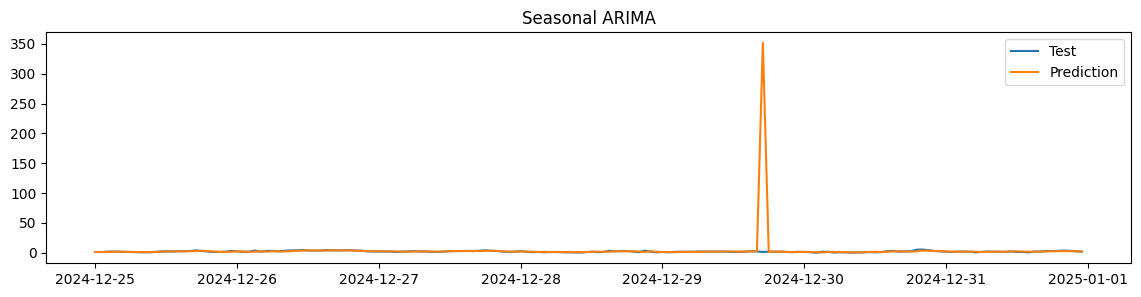

In [113]:
show_comparison(test_data,sarima_pred_1h,"Seasonal ARIMA")

In [112]:
sarima_results = apply_test(test_data,sarima_pred_1h,"Seasonal ARIMA")

MAPE: 191.45764049163333
MAE: 2.5778059345238096
MSE: 731.9386484151707
RMSE: 27.05436468326637
     lb_stat  lb_pvalue
1   0.004684   0.945437
2   0.010599   0.994714
3   0.016926   0.999417
4   0.019289   0.999954
5   0.020380   0.999997
6   0.026249   1.000000
7   0.032378   1.000000
8   0.038797   1.000000
9   0.042124   1.000000
10  0.061650   1.000000
11  0.074176   1.000000
12  0.076707   1.000000
13  0.084763   1.000000
14  0.092564   1.000000
15  0.099457   1.000000
16  0.102858   1.000000
17  0.113096   1.000000
18  0.114817   1.000000
19  0.116221   1.000000
20  0.147939   1.000000


##### 3.3.1 Corrigiendo Dato atipico

In [114]:
sarima_pred_1h[sarima_pred_1h>5] = sarima_pred_1h.mean()

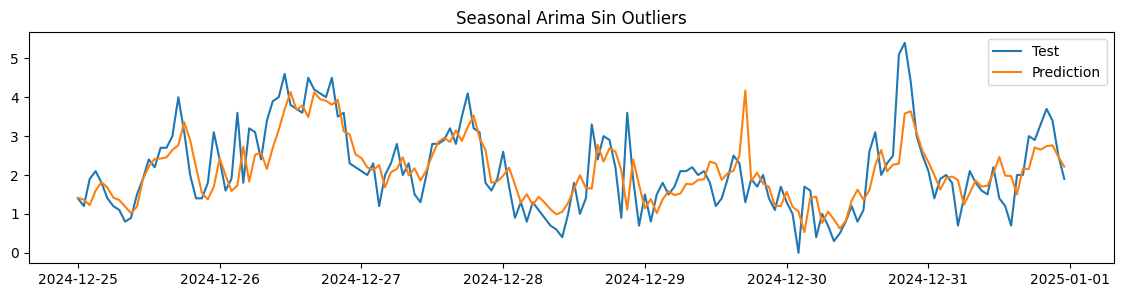

In [115]:
show_comparison(test_data,sarima_pred_1h,"Seasonal Arima Sin Outliers")

In [117]:
sarima_results_2 = apply_test(test_data,sarima_pred_1h,"Seasonal Arima Sin Outliers")

MAPE: 31.308247686584135
MAE: 0.5082563405966554
MSE: 0.4918533177568448
RMSE: 0.7013225490149627
      lb_stat  lb_pvalue
1    1.589918   0.207338
2    1.716894   0.423820
3    1.900268   0.593362
4    2.369074   0.668223
5    2.998372   0.700237
6    5.159154   0.523569
7    5.199904   0.635583
8    8.386881   0.396619
9    8.485578   0.486046
10   9.083366   0.524211
11   9.104111   0.612283
12  11.869071   0.456251
13  11.877510   0.537713
14  14.776347   0.393612
15  15.535621   0.413567
16  16.013833   0.451996
17  17.766724   0.403699
18  17.788002   0.469699
19  19.959325   0.397030
20  21.613111   0.361868


#### 3.4 Perceptron Multicapas (MLP)

In [132]:
MLP_1h = keras.models.Sequential([
    keras.layers.Dense(128, kernel_initializer='he_normal', activation='relu', input_dim=48),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, kernel_initializer='he_normal', activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, kernel_initializer='he_normal', activation='relu'),
    keras.layers.Dense(16, kernel_initializer='he_normal', activation='relu'),
    keras.layers.Dense(1, activation='linear')
])

MLP_1h.compile(optimizer='adam', loss='huber')

C:\Users\Martin Bornacelly\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [133]:
early_stopping = keras.callbacks.EarlyStopping(monitor = 'val_loss',
                                               patience = 50,
                                               verbose = 1,
                                               restore_best_weights = True)

In [134]:
MLP_1h.fit(train_x, train_y,
          epochs=1000,
          callbacks=[early_stopping],
          validation_data=(validation_x,validation_y),
          shuffle=False)

Epoch 1/1000
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.3156 - val_loss: 0.2685
Epoch 2/1000
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2377 - val_loss: 0.2930
Epoch 3/1000
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2248 - val_loss: 0.3040
Epoch 4/1000
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2196 - val_loss: 0.3184
Epoch 5/1000
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2154 - val_loss: 0.3119
Epoch 6/1000
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2117 - val_loss: 0.3101
Epoch 7/1000
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2102 - val_loss: 0.3269
Epoch 8/1000
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2097 - val_loss: 0.2875
Epoch 9/1000
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2082 - val_loss: 0.2980
Epoch 10/1000
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2067 - val_loss: 0.3077
Epoch 11/1000
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2056 - val_loss: 0.2995
Epoch 12

In [135]:
mlp_pred_1h = MLP_1h.predict(test_x).flatten()
mlp_pred_1h = pd.DataFrame(mlp_pred_1h)
mlp_pred_1h.index = test_data.index[48:]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


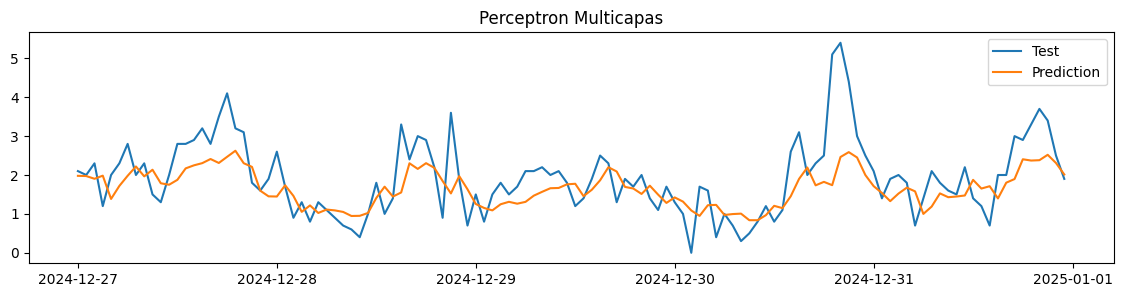

In [136]:
show_comparison(test_data[48:],mlp_pred_1h,"Perceptron Multicapas")

In [137]:
mlp_results = apply_test(np.array(test_data[48:]),np.array(mlp_pred_1h).flatten(),"Perceptron Multicapas")

MAPE: 33.37808548833448
MAE: 0.5602272435029348
MSE: 0.5841828576418554
RMSE: 0.7643185576981991
      lb_stat  lb_pvalue
1   14.769840   0.000121
2   17.137227   0.000190
3   18.605313   0.000330
4   20.810272   0.000345
5   21.328789   0.000702
6   21.845791   0.001291
7   21.961737   0.002579
8   24.824103   0.001665
9   25.101505   0.002861
10  26.888281   0.002712
11  27.562012   0.003776
12  27.567066   0.006397
13  28.463207   0.007794
14  32.213670   0.003735
15  34.705160   0.002708
16  34.949322   0.004038
17  39.438894   0.001552
18  41.926962   0.001132
19  46.713868   0.000392
20  47.735084   0.000463


#### 3.5 Redes Neuronales Recurrentes (RNN)

In [139]:
RNN_1h = keras.models.Sequential([
    keras.layers.SimpleRNN(128, activation='tanh', return_sequences=True, input_shape=(48, 1)),
    keras.layers.Dropout(0.2),
    keras.layers.SimpleRNN(64, activation='tanh', return_sequences=True),
    keras.layers.Dropout(0.2),
    keras.layers.SimpleRNN(32, activation='tanh', return_sequences=True),
    keras.layers.SimpleRNN(16, activation='tanh', return_sequences=False),
    keras.layers.Dense(1, activation='linear')  # Predicción de viento
])

RNN_1h.compile(optimizer='adam', loss='huber')

C:\Users\Martin Bornacelly\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [140]:
early_stopping = keras.callbacks.EarlyStopping(monitor = 'val_loss',
                                               patience = 50,
                                               verbose = 1,
                                               restore_best_weights = True)

In [141]:
RNN_1h.fit(train_x, train_y,
          epochs=1000,
          callbacks=[early_stopping],
          validation_data=(validation_x,validation_y),
          shuffle=False)

Epoch 1/1000
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - loss: 0.3127 - val_loss: 0.2007
Epoch 2/1000
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 33s 20ms/step - loss: 0.2417 - val_loss: 0.2185
Epoch 3/1000
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 46s 28ms/step - loss: 0.2358 - val_loss: 0.2122
Epoch 4/1000
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 43s 26ms/step - loss: 0.2387 - val_loss: 0.2034
Epoch 5/1000
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 34s 21ms/step - loss: 0.2313 - val_loss: 0.2050
Epoch 6/1000
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - loss: 0.2365 - val_loss: 0.2058
Epoch 7/1000
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - loss: 0.2314 - val_loss: 0.2068
Epoch 8/1000
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - loss: 0.2303 - val_loss: 0.2066
Epoch 9/1000
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 36s 22ms/step - loss: 0.2372 - val_loss: 0.2089
Epoch 10/1000
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - loss: 0.2320 - val_loss: 0.2013
Epoch 11/1000
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 36s 22ms/step - loss: 0.2280 - val

In [142]:
RNN_pred_1h = RNN_1h.predict(test_x).flatten()
RNN_pred_1h = pd.DataFrame(RNN_pred_1h)
RNN_pred_1h.index = test_data.index[48:]

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step


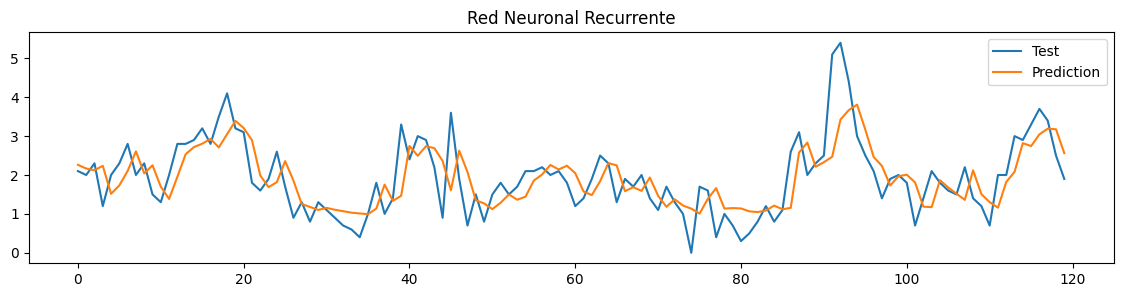

In [143]:
show_comparison(np.array(test_data[48:]),np.array(RNN_pred_1h).flatten(),"Red Neuronal Recurrente")

In [144]:
RNN_results = apply_test(np.array(test_data[48:]),np.array(RNN_pred_1h).flatten(),"Red Neuronal Recurrente")

MAPE: 36.317709705697155
MAE: 0.5253893717130026
MSE: 0.4799027411903604
RMSE: 0.6927501289717386
      lb_stat  lb_pvalue
1    1.816509   0.177729
2    3.573947   0.167466
3    4.035180   0.257690
4    4.049688   0.399323
5    4.195363   0.521645
6    4.750282   0.576217
7    4.808688   0.683297
8    9.434684   0.306963
9    9.589966   0.384687
10  11.059806   0.352878
11  11.422192   0.408601
12  12.243237   0.426348
13  12.254855   0.506865
14  13.520377   0.486019
15  14.130301   0.515671
16  14.319021   0.574961
17  14.806809   0.609395
18  14.820811   0.674232
19  16.216192   0.642808
20  16.256946   0.700561


#### 3.6 Long-Short Term Memory (LSTM)

In [145]:
LSTM_1h = keras.models.Sequential([
    keras.layers.LSTM(64, return_sequences=True, input_shape=(48,1)),
    keras.layers.Dropout(0.2),
    keras.layers.LSTM(32, return_sequences=True),
    keras.layers.Dropout(0.2),
    keras.layers.LSTM(16, return_sequences=True),
    keras.layers.LSTM(8,  return_sequences=False),
    keras.layers.Dense(1, activation='linear')
])

LSTM_1h.compile(optimizer = 'adam', loss = 'mean_squared_error')

C:\Users\Martin Bornacelly\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [146]:
early_stopping = keras.callbacks.EarlyStopping(monitor = 'val_loss',
                                               patience = 50,
                                               verbose = 1,
                                               restore_best_weights = True)

In [147]:
LSTM_1h.fit(train_x, train_y,
          epochs=400,
          callbacks=[early_stopping],
          validation_data=(validation_x,validation_y),
          shuffle=False)

Epoch 1/400
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 66s 37ms/step - loss: 1.4269 - val_loss: 0.4442
Epoch 2/400
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 55s 33ms/step - loss: 0.4997 - val_loss: 0.4124
Epoch 3/400
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 57s 35ms/step - loss: 0.4582 - val_loss: 0.4085
Epoch 4/400
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 52s 32ms/step - loss: 0.4495 - val_loss: 0.4060
Epoch 5/400
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 51s 31ms/step - loss: 0.4452 - val_loss: 0.4033
Epoch 6/400
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 48s 29ms/step - loss: 0.4414 - val_loss: 0.4035
Epoch 7/400
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 50s 30ms/step - loss: 0.4382 - val_loss: 0.4023
Epoch 8/400
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 49s 30ms/step - loss: 0.4354 - val_loss: 0.4014
Epoch 9/400
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - loss: 0.4337 - val_loss: 0.3996
Epoch 10/400
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 49s 30ms/step - loss: 0.4335 - val_loss: 0.3984
Epoch 11/400
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 49s 30ms/step - loss: 0.4314 - val_loss: 0.39

In [148]:
LSTM_pred_1h = LSTM_1h.predict(test_x).flatten()
LSTM_pred_1h = pd.DataFrame(LSTM_pred_1h)
LSTM_pred_1h.index = test_data.index[48:]

1/4 ━━━━━━━━━━━━━━━━━━━━ 1s 448ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000180B60CFB00> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step


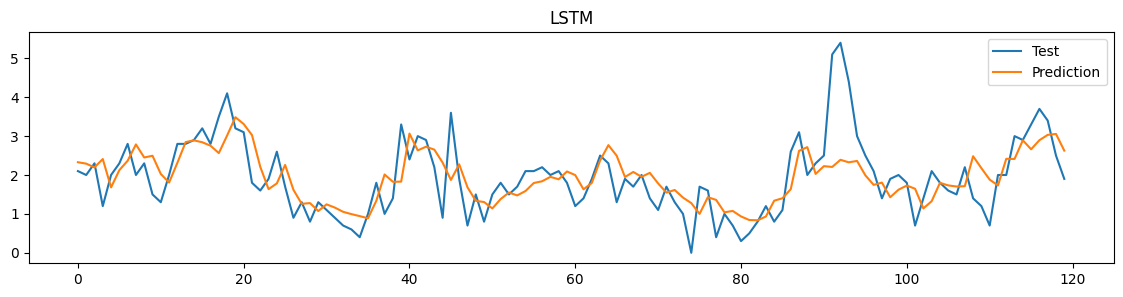

In [149]:
show_comparison(np.array(test_data[48:]),np.array(LSTM_pred_1h).flatten(), "LSTM")

In [150]:
LSTM_results = apply_test(np.array(test_data[48:]),np.array(LSTM_pred_1h).flatten(), "LSTM")

MAPE: 35.77554540417541
MAE: 0.5333727165063222
MSE: 0.5300419650207597
RMSE: 0.7280398100521425
      lb_stat  lb_pvalue
1   10.810349   0.001009
2   11.925582   0.002573
3   12.933671   0.004782
4   13.906492   0.007600
5   13.960603   0.015862
6   15.485954   0.016796
7   15.617126   0.028854
8   17.042045   0.029674
9   17.118585   0.046891
10  17.236714   0.069287
11  17.251470   0.100654
12  17.926032   0.117955
13  18.028763   0.156430
14  20.894898   0.104356
15  23.372819   0.076539
16  23.774858   0.094538
17  26.961578   0.058634
18  28.285573   0.057840
19  32.031648   0.030999
20  33.372169   0.030699


### 4. Resultados

In [164]:
def dm_test(errors_1, errors_2, alpha = 0.05):

    d = np.abs(errors_1) - np.abs(errors_2)  
    d_mean = np.mean(d)
    n = len(d)
    h = int(n**(1/3) + 1)

    gamma = acf(d, nlags=n-1, fft=False)
    
    DM_stat = d_mean / np.sqrt( (gamma[0] + 2 * np.sum(gamma[1:h])) / n )
        
    z_crit = norm.ppf(1 - alpha / 2)

    reject_null = np.abs(DM_stat) > z_crit

    return DM_stat, reject_null

In [172]:
modelos = ['Suavización exponencial Holt-Winters Primer Orden',
           'Suavización exponencial Holt-Winters Segundo Orden',
           'Suavización exponencial Holt-Winters Tercer Orden',
           'Perceptron Multicapas',
           'Red Neuronal Recurrente',
           'LSTM']

In [174]:
for modelo1 in modelos:
    # Encontrar el residuo del modelo1
    error1 = pd.read_csv(f'{modelo1} Info.csv')['residuals']
    # Verificar si es diferente a todos
    reject_global = True
    for modelo2 in modelos:
        # No comparar mismo modelo
        if modelo1 == modelo2:
            continue
        # Encontrar el residuo del modelo2
        error2 = pd.read_csv(f'{modelo2} Info.csv')['residuals']
        # Hacer Test
        dm, reject = dm_test(error1,error2)
        if reject != False:
            reject_global = False
            print(f"Las predicciones del {modelo1} no son siginificativamente diferentes a {modelo2}.")
    if reject_global:
        print(f"Las predicciones del {modelo1} son siginificativamente diferentes a todos los demas modelos.")

Las predicciones del Suavización exponencial Holt-Winters Primer Orden no son siginificativamente diferentes a Suavización exponencial Holt-Winters Tercer Orden.
Las predicciones del Suavización exponencial Holt-Winters Segundo Orden no son siginificativamente diferentes a Suavización exponencial Holt-Winters Tercer Orden.
Las predicciones del Suavización exponencial Holt-Winters Tercer Orden no son siginificativamente diferentes a Suavización exponencial Holt-Winters Primer Orden.
Las predicciones del Suavización exponencial Holt-Winters Tercer Orden no son siginificativamente diferentes a Suavización exponencial Holt-Winters Segundo Orden.
Las predicciones del Perceptron Multicapas son siginificativamente diferentes a todos los demas modelos.
Las predicciones del Red Neuronal Recurrente son siginificativamente diferentes a todos los demas modelos.
Las predicciones del LSTM son siginificativamente diferentes a todos los demas modelos.
